<a href="https://colab.research.google.com/github/AnnisaFarikha/Visi-Komputer/blob/main/Jobsheet02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


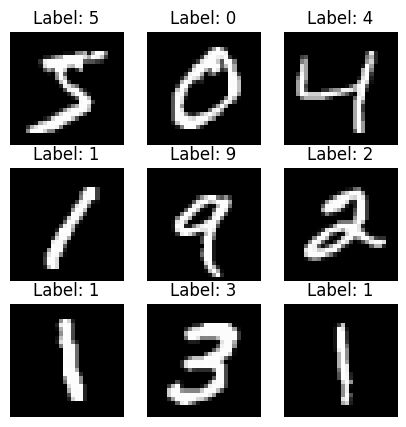

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

###range = 25 ; plt.subplot = 5,5

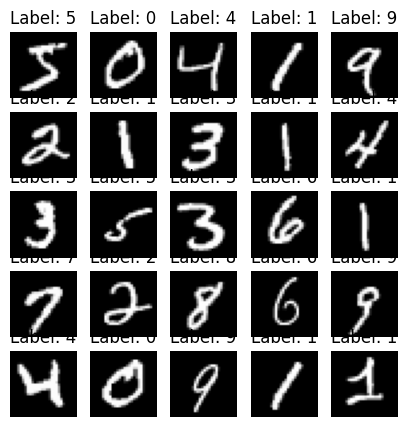

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

##Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) #gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:",accuracy_score(y_test, y_pred))

Akurasi: 0.9101


###kernel = rbf

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) #gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:",accuracy_score(y_test, y_pred))

Akurasi: 0.9513


##Praktikum D3 - Membangun CNN Sederhana

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9491 - loss: 0.1740 - val_accuracy: 0.9793 - val_loss: 0.0718
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9827 - loss: 0.0579 - val_accuracy: 0.9845 - val_loss: 0.0556
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9872 - loss: 0.0407 - val_accuracy: 0.9830 - val_loss: 0.0614
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9910 - loss: 0.0289 - val_accuracy: 0.9863 - val_loss: 0.0528
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9932 - loss: 0.0209 - val_accuracy: 0.9865 - val_loss: 0.0519


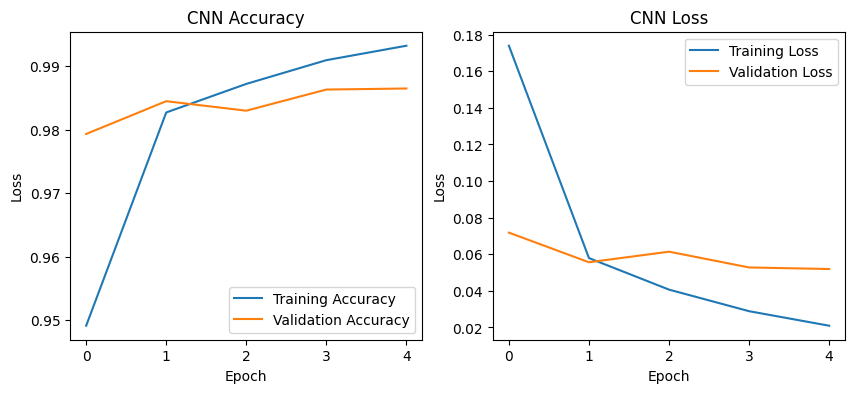

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

###tambah satu lapisan Conv2D sebelum Flatten

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9552 - loss: 0.1474 - val_accuracy: 0.9822 - val_loss: 0.0567
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9848 - loss: 0.0500 - val_accuracy: 0.9885 - val_loss: 0.0416
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.9888 - val_loss: 0.0365
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 25ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9880 - val_loss: 0.0427
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9942 - loss: 0.0168 - val_accuracy: 0.9910 - val_loss: 0.0411


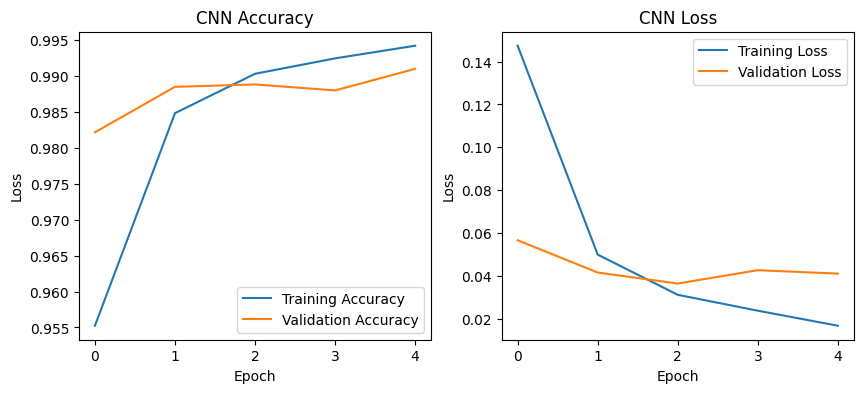

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##Praktikum D4 - Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.4397 - loss: 1.5587 - val_accuracy: 0.5260 - val_loss: 1.3237
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.5765 - loss: 1.2030 - val_accuracy: 0.6138 - val_loss: 1.1116
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 41ms/step - accuracy: 0.6254 - loss: 1.0653 - val_accuracy: 0.6376 - val_loss: 1.0364
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.6563 - loss: 0.9873 - val_accuracy: 0.6486 - val_loss: 1.0002
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6756 - loss: 0.9272 - val_accuracy: 0.6652 - val_loss: 0.9651
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.6937 - loss: 0.8845 - val_accuracy: 0.6686 - val_loss: 0.9501
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7065 - loss: 0.8393 - val_accuracy: 0.6642 - val_loss: 0.9953
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.7208 -

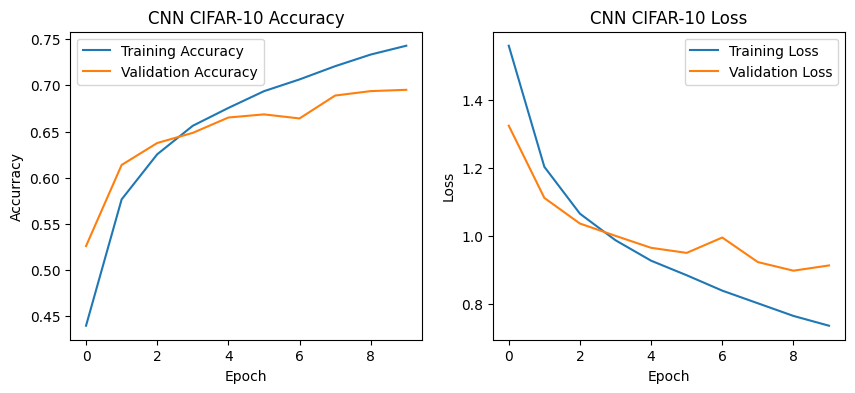

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3),
    activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accurracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

###tambahkan Dropout(0.5) sebelum lapisan Dens terakhir

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 45ms/step - accuracy: 0.1155 - loss: 8.4076 - val_accuracy: 0.0986 - val_loss: 86.1501
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.1031 - loss: 8.4966 - val_accuracy: 0.0986 - val_loss: 213.4557
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.1002 - loss: 8.4484 - val_accuracy: 0.0986 - val_loss: 286.2902
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.1002 - loss: 8.4139 - val_accuracy: 0.0986 - val_loss: 286.2902
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.1002 - loss: 8.3971 - val_accuracy: 0.0986 - val_loss: 286.2902
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.1002 - loss: 8.3655 - val_accuracy: 0.0986 - val_loss: 286.2902
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.1002 - loss: 8.4392 - val_accuracy: 0.0986 - val_loss: 286.2902
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accur

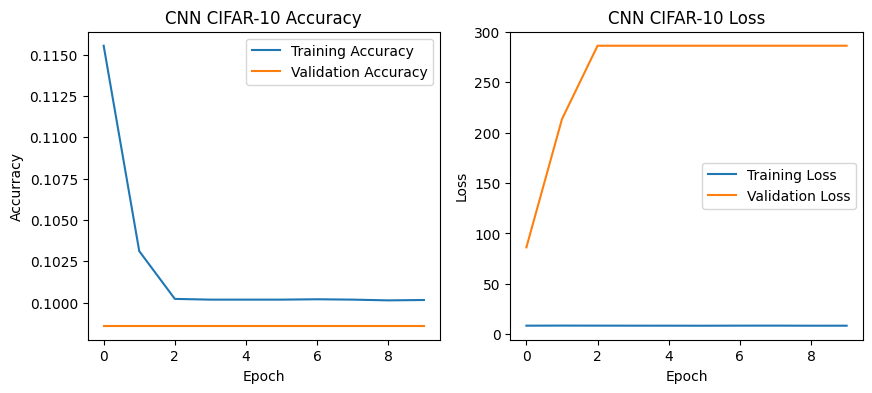

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3),
    activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
    layers.Dropout(0.5)
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accurracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##Praktikum D5 - Transfer Learning dengan Model Pra-Latih

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 633s 449ms/step - accuracy: 0.5166 - loss: 1.3852 - val_accuracy: 0.5570 - val_loss: 1.2522
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 628s 446ms/step - accuracy: 0.5808 - loss: 1.1994 - val_accuracy: 0.5832 - val_loss: 1.1698
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 620s 441ms/step - accuracy: 0.6025 - loss: 1.1392 - val_accuracy: 0.6002 - val_loss: 1.1338
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 613s 436ms/step - accuracy: 0.6140 - loss: 1.1008 - val_accuracy: 0.6084 - val_loss: 1.1214
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 612s 435ms/step - accuracy: 0.6260 - loss: 1.0683 - val_accuracy: 0.6064 - val_loss: 1.1075


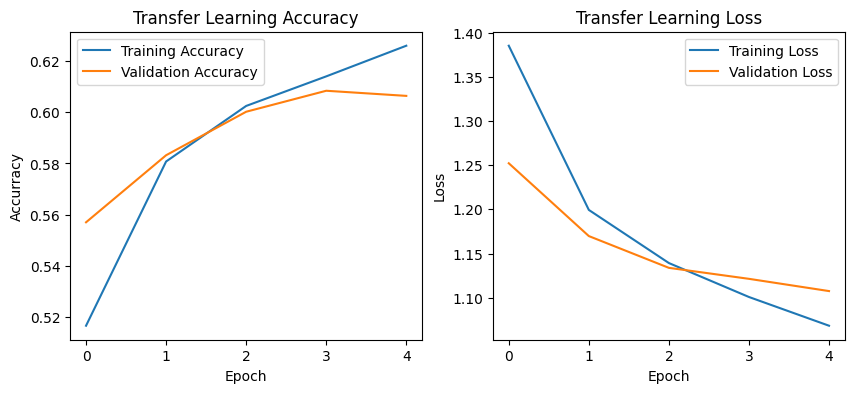

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accurracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

###aktifkan 1–2 lapisan terakhir dari base_model (fine-tuning)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 35s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4842s 3s/step - accuracy: 0.2796 - loss: 1.8096 - val_accuracy: 0.3640 - val_loss: 1.6182
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4917s 3s/step - accuracy: 0.4875 - loss: 1.3442 - val_accuracy: 0.4676 - val_loss: 1.3885
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4840s 3s/step - accuracy: 0.5909 - loss: 1.1311 - val_accuracy: 0.6644 - val_loss: 0.9455
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4834s 3s/step - accuracy: 0.6738 - loss: 0.9152 - val_accuracy: 0.6902 - val_loss: 0.8871
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4897s 3s/step - accuracy: 0.7223 - loss: 0.7968 - val_accuracy: 0.7296 - val_loss: 0.7728


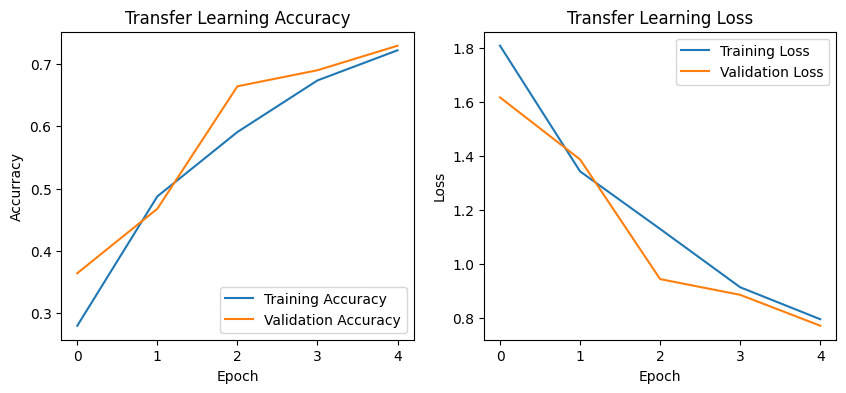

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accurracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##Praktikum D6 - Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 397ms/step
              precision    recall  f1-score   support

           0       0.63      0.72      0.67      1000
           1       0.63      0.72      0.67      1000
           2       0.62      0.41      0.49      1000
           3       0.41      0.47      0.43      1000
           4       0.58      0.50      0.54      1000
           5       0.50      0.55      0.52      1000
           6       0.60      0.70      0.65      1000
           7       0.68      0.66      0.67      1000
           8       0.70      0.75      0.73      1000
           9       0.71      0.49      0.58      1000

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.60      0.60      0.60     10000



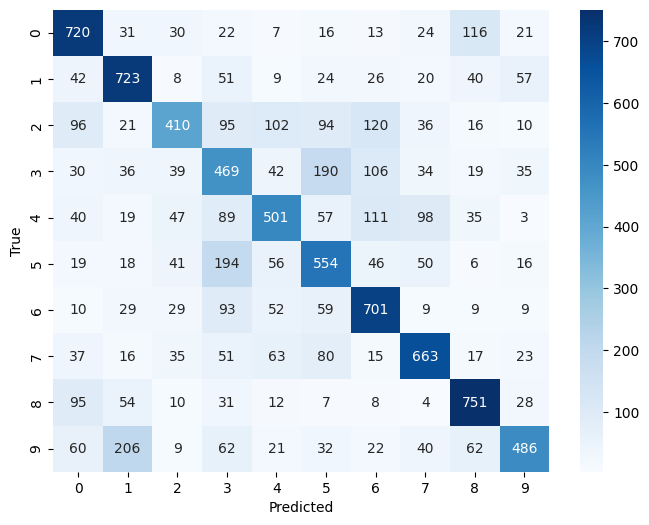

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

##Tugas A (Prediksi dengan CNN dari D3)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.9557 - loss: 0.1468 - val_accuracy: 0.9833 - val_loss: 0.0558
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9860 - loss: 0.0455 - val_accuracy: 0.9848 - val_loss: 0.0551
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.9898 - loss: 0.0311 - val_accuracy: 0.9883 - val_loss: 0.0391
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9936 - loss: 0.0205 - val_accuracy: 0.9892 - val_loss: 0.0381
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.9951 - loss: 0.0156 - val_accuracy: 0.9883 - val_loss: 0.0401


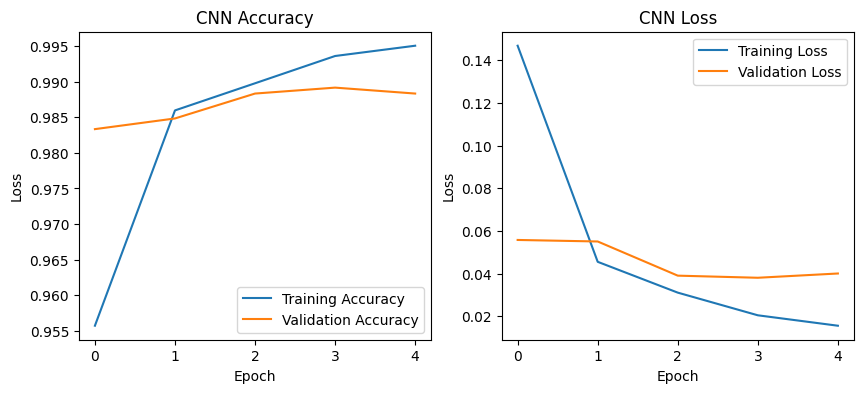

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
  """ Langkah:
    • Konversi ke grayscale
    • Auto-contrast
    • (Opsional) invert bila latar terang (agar digit jadi putih, latar jadi gelap seperti MNIST)
    • Crop ke bounding box digit
    • Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    • Normalisasi ke [0,1] dan tambah axis channel """
  # Grayscale + autocontrast
  img = img_pil.convert('L')
  img = ImageOps.autocontrast(img)

  arr = np.array(img).astype(np.uint8)
  # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap (gaya MNIST)
  if arr.mean() > 127:
    img = ImageOps.invert(img)
    arr = np.array(img)

  # Binarisasi ringan untuk cari bbox digit
  thr = np.mean(arr) * 0.8 # ambang adaptif sederhana
  mask = arr > thr
  if mask.any():
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    img = img.crop((x0, y0, x1+1, y1+1))

  # Resize ke 20x20 dengan aspect ratio
  img.thumbnail((20, 20), Image.Resampling.LANCZOS)
  w, h = img.size

  # Pad ke 28x28 dan center
  canvas = Image.new('L', (28, 28), color=0)
  canvas.paste(img, ((28 - w)//2, (28 - h)//2))

  # Normalisasi ke [0,1]
  arr = np.array(canvas).astype('float32') / 255.0
  # Tambah channel dim (28,28,1)
  arr = arr[..., None]
  return canvas, arr

Saving 368.jpeg to 368 (4).jpeg


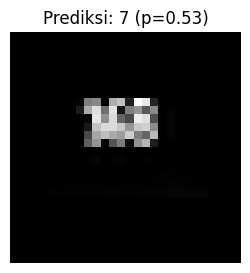

Rekap Prediksi (CNN):
- 368 (4).jpeg -> 7 (p=0.534)


In [ ]:
import matplotlib.pyplot as plt

results = []
for fname in uploaded.keys():
  img_pil = Image.open(fname)
  disp, x = preprocess_to_mnist_28x28(img_pil) #disp: PIL untuk ditampilkan, x: (28,28,1)
  x_batch = np.expand_dims(x, axis=0)          #(1,28,28,1)
  probs = model.predict(x_batch, verbose=0)[0] #shape (10,)
  pred = int(np.argmax(probs))
  conf = float(np.max(probs))

  results.append((fname, pred, conf))

  # Tampilkan hasil
  plt.figure(figsize=(3,3))
  plt.imshow(disp, cmap='gray')
  plt.title(f"Prediksi: {pred} (p={conf:.2f})")
  plt.axis('off')
  plt.show()

# Rekap ringkas
print("Rekap Prediksi (CNN):")
for r in results:
  print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")

##Tugas B (Prediksi dengan SVM dari D2)


In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score
import tensorflow as tf

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) #gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:",accuracy_score(y_test, y_pred))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Akurasi: 0.9513


In [ ]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

Saving 368.jpeg to 368 (5).jpeg


In [ ]:
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
  """ Langkah:
    • Konversi ke grayscale
    • Auto-contrast
    • (Opsional) invert bila latar terang (agar digit jadi putih, latar jadi gelap seperti MNIST)
    • Crop ke bounding box digit
    • Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    • Normalisasi ke [0,1] dan tambah axis channel """
  # Grayscale + autocontrast
  img = img_pil.convert('L')
  img = ImageOps.autocontrast(img)

  arr = np.array(img).astype(np.uint8)
  # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap (gaya MNIST)
  if arr.mean() > 127:
    img = ImageOps.invert(img)
    arr = np.array(img)

  # Binarisasi ringan untuk cari bbox digit
  thr = np.mean(arr) * 0.8 # ambang adaptif sederhana
  mask = arr > thr
  if mask.any():
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    img = img.crop((x0, y0, x1+1, y1+1))

  # Resize ke 20x20 dengan aspect ratio
  img.thumbnail((20, 20), Image.Resampling.LANCZOS)
  w, h = img.size

  # Pad ke 28x28 dan center
  canvas = Image.new('L', (28, 28), color=0)
  canvas.paste(img, ((28 - w)//2, (28 - h)//2))

  # Normalisasi ke [0,1]
  arr = np.array(canvas).astype('float32') / 255.0
  # Tambah channel dim (28,28,1)
  arr = arr[..., None]
  return canvas, arr

In [ ]:
from sklearn.metrics import accuracy_score

results = []
for fname in uploaded.keys():
  img_pil = Image.open(fname)
  _, x = preprocess_to_mnist_28x28(img_pil)	#x: (28,28,1) float [0,1]
  x_flat = x.reshape(1, -1)	                #(1,784)

  pred = int(clf.predict(x_flat)[0])
  # SVM default tidak punya proba kecuali SVC(probability=True). Jika Anda ingin probabilitas:
  # clf = svm.SVC(kernel='rbf', gamma='scale', probability=True) saat pelatihan.
  conf = None
  try:
    if hasattr(clf, "predict_proba"):
      conf = float(np.max(clf.predict_proba(x_flat)))
  except Exception:
    pass

  results.append((fname, pred, conf))

  # Tampilkan hasil (gunakan gambar 28x28 yang sudah diproses di tahap CNN juga boleh)
  print(f"{fname} -> Prediksi SVM: {pred}" + (f" (p≈{conf:.2f})" if conf is not None else ""))

368 (5).jpeg -> Prediksi SVM: 7
